In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv(r"C:\Users\Manyata Sachin kadam\Desktop\smart towing intelligence system\Backend\Pune_With_Real_Features_v5.csv", 
                    encoding='latin-1')

print(data.head())


                                           Road Name            Division Name  \
0  FC Road (Fergusson College Road) & JM Road (Ja...  Deccan Traffic Division   
1  Goodluck Cafe Lane: The stretch from Goodluck ...  Deccan Traffic Division   
2  akatdar Path Road (Deccan/Chaturshringi border...  Deccan Traffic Division   
3  Near Junctions and Bus Stands: Parking within ...  Deccan Traffic Division   
4  The Riverbed Road: While parts are used for pa...  Deccan Traffic Division   

  Date Type  near_junction  near_bus_stop  near_highway  footpath_violation  \
0       Odd              0              0             0                   0   
1      Even              0              0             0                   0   
2      Both              0              0             0                   0   
3      Both              1              1             0                   0   
4      Both              0              0             0                   0   

   both_sides_banned  immediate_tow_me

In [2]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Road Name                297 non-null    object
 1   Division Name            297 non-null    object
 2   Date Type                297 non-null    object
 3   near_junction            297 non-null    int64 
 4   near_bus_stop            297 non-null    int64 
 5   near_highway             297 non-null    int64 
 6   footpath_violation       297 non-null    int64 
 7   both_sides_banned        297 non-null    int64 
 8   immediate_tow_mention    297 non-null    int64 
 9   near_landmark            297 non-null    int64 
 10  zero_tolerance           297 non-null    int64 
 11  description_length       297 non-null    int64 
 12  Yard Name                297 non-null    object
 13  narrow_road              297 non-null    int64 
 14  residential_society      297 non-null    i

In [3]:
print(data.isnull().sum())


Road Name                  0
Division Name              0
Date Type                  0
near_junction              0
near_bus_stop              0
near_highway               0
footpath_violation         0
both_sides_banned          0
immediate_tow_mention      0
near_landmark              0
zero_tolerance             0
description_length         0
Yard Name                  0
narrow_road                0
residential_society        0
no_parking_explicit        0
meters_distance_mention    0
market_area                0
Towed                      0
dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Road Name', 'Division Name', 'Date Type', 'near_landmark', 'Yard Name']

le_dict = {}

for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    le_dict[col] = le

In [5]:
X = data.drop(['Towed','zero_tolerance'], axis=1)
y = data['zero_tolerance']
print(X, y)

     Road Name  Division Name  Date Type  near_junction  near_bus_stop  \
0           75             13          2              0              0   
1           87             13          1              0              0   
2          296             13          0              0              0   
3          154             13          0              1              1   
4          280             13          0              0              0   
..         ...            ...        ...            ...            ...   
292         83              8          1              0              0   
293        235              8          2              0              0   
294        288              8          2              1              0   
295        191              8          2              1              0   
296        275              8          2              1              1   

     near_highway  footpath_violation  both_sides_banned  \
0               0                   0              

In [6]:
print(X.columns.tolist())
print(y.name)

['Road Name', 'Division Name', 'Date Type', 'near_junction', 'near_bus_stop', 'near_highway', 'footpath_violation', 'both_sides_banned', 'immediate_tow_mention', 'near_landmark', 'description_length', 'Yard Name', 'narrow_road', 'residential_society', 'no_parking_explicit', 'meters_distance_mention', 'market_area']
zero_tolerance


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=50)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:", model.score(X_test, y_test))
# Accuracy=0.67

Logistic Regression Accuracy: 0.6333333333333333


c:\Users\Manyata Sachin kadam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56        39
           1       0.67      0.71      0.69        51

    accuracy                           0.63        90
   macro avg       0.62      0.62      0.62        90
weighted avg       0.63      0.63      0.63        90



In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("K Nearest Neighbors Accuracy:", knn.score(X_test, y_test))

# Accuracy=0.65

K Nearest Neighbors Accuracy: 0.6333333333333333


In [11]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.44      0.51        39
           1       0.65      0.78      0.71        51

    accuracy                           0.63        90
   macro avg       0.63      0.61      0.61        90
weighted avg       0.63      0.63      0.62        90



In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree Classifier Accuracy:", model.score(X_test, y_test))

#Accurancy=0.61

Decision Tree Classifier Accuracy: 0.6111111111111112


In [13]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.74      0.62        39
           1       0.72      0.51      0.60        51

    accuracy                           0.61        90
   macro avg       0.63      0.63      0.61        90
weighted avg       0.64      0.61      0.61        90



In [14]:
from sklearn.svm import SVC
classifier = SVC(kernel='poly', random_state = 42)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print("Support Vector Machine Accuracy:", classifier.score(X_test, y_test))
#Accuracy=0.58

Support Vector Machine Accuracy: 0.5666666666666667


In [15]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.57      1.00      0.72        51

    accuracy                           0.57        90
   macro avg       0.28      0.50      0.36        90
weighted avg       0.32      0.57      0.41        90



c:\Users\Manyata Sachin kadam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manyata Sachin kadam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manyata Sachin kadam\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=400,class_weight='balanced',random_state=47)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
print("Random Forest Classifier Accuracy:", rf_classifier.score(X_test, y_test))
#Accuracy=0.72

Random Forest Classifier Accuracy: 0.7333333333333333


In [17]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.56      0.65        39
           1       0.72      0.86      0.79        51

    accuracy                           0.73        90
   macro avg       0.74      0.71      0.72        90
weighted avg       0.74      0.73      0.73        90



In [18]:
from sklearn.metrics import confusion_matrix
print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[22 17]
 [ 7 44]]


In [19]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# ── 1. Load Data ──────────────────────────────────────────────
data = pd.read_csv(r"C:\Users\Manyata Sachin kadam\Desktop\smart towing intelligence system\Backend\Pune_With_Real_Features_v5.csv",
                    encoding='latin-1')

def word_in_text(text, words):
    for w in words:
        if re.search(r'\b' + re.escape(w) + r'\b', str(text).lower()):
            return 1
    return 0

# zero_tolerance_kw feature (description varun)
data['zero_tolerance_kw'] = data['Road Name'].apply(
    lambda x: word_in_text(x, ['zero tolerance', 'strictly prohibited',
                                'strictly banned', 'absolute ban'])
)

# ── 2. Encode ─────────────────────────────────────────────────
le_div  = LabelEncoder()
le_date = LabelEncoder()
le_div.fit(data['Division Name'])
le_date.fit(data['Date Type'])
data['div_enc']  = le_div.transform(data['Division Name'])
data['date_enc'] = le_date.transform(data['Date Type'])

features = ['near_junction', 'near_bus_stop', 'near_highway',
            'footpath_violation', 'both_sides_banned',
            'immediate_tow_mention', 'near_landmark',
            'narrow_road', 'no_parking_explicit',
            'meters_distance_mention', 'market_area',
            'zero_tolerance_kw', 'description_length',
            'div_enc', 'date_enc']

X = data[features]
y = data['zero_tolerance']

# ── 3. Train Final Model (full data var — train-test split nako, model already validate kela aahe) ──
model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
model.fit(X, y)

print("✅ Model Ready! (Validated Accuracy: 73%)\n")

# ── 4. Feature Extraction Function ───────────────────────────
def extract_features(text):
    t = str(text).lower()
    return {
        'near_junction': word_in_text(t, ['junction','chowk','intersection','crossing']),
        'near_bus_stop': word_in_text(t, ['bus stop','bus stand','depot','pmpml']),
        'near_highway': word_in_text(t, ['highway','nh-','bypass','expressway']),
        'footpath_violation': word_in_text(t, ['footpath','pavement','sidewalk']),
        'both_sides_banned': word_in_text(t, ['both sides','either side']),
        'immediate_tow_mention': word_in_text(t, ['immediately towed','tow away','will be towed']),
        'near_landmark': word_in_text(t, ['temple','college','hospital','market','school','station']),
        'narrow_road': word_in_text(t, ['narrow','tight lane']),
        'no_parking_explicit': word_in_text(t, ['no parking']),
        'meters_distance_mention': word_in_text(t, ['meters','metre']),
        'market_area': word_in_text(t, ['market','bazaar']),
        'zero_tolerance_kw': word_in_text(t, ['zero tolerance','strictly prohibited','strictly banned','absolute ban']),
        'description_length': len(str(text)),
    }

# ── 5. User Input ─────────────────────────────────────────────
road_name = input("Which road was your vehicle parked on? ")

# Search division from database (road match found tar)
match = data[data['Road Name'].str.contains(road_name, case=False, na=False)]

if not match.empty:
    division_name = match.iloc[0]['Division Name']
    print(f"\n✅ Road found in database. Division: {division_name}")
else:
    division_name = input("Road not in database. Enter your Division Name: ")
    if division_name not in le_div.classes_:
        print(f"\n❌ '{division_name}' is not a valid division.")
        print(f"Available divisions: {list(le_div.classes_)}")
        exit()

date_type = input("Date Type (Odd/Even/Both) [default=Both]: ") or 'Both'
if date_type not in le_date.classes_:
    date_type = 'Both'

# ── 6. Build Feature Vector ──────────────────────────────────
# Jar road match zala tar tyache actual description vaapara, nahitar road…
# road_name text vaapara
input_text = match.iloc[0]['Road Name'] if not match.empty else road_name

feats = extract_features(input_text)
feats['div_enc'] = le_div.transform([division_name])[0]
feats['date_enc'] = le_date.transform([date_type])[0]

input_df = pd.DataFrame([feats])[features]

# ── 7. ML PREDICTION ──────────────────────────────────────────
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0]
confidence = probability.max() * 100

yard_name = match.iloc[0]['Yard Name'] if not match.empty else division_name.replace('Traffic Division', 'Traffic Yard')

print(f"\n{'='*55}")
print(f"  ML PREDICTION RESULT")
print(f"{'='*55}")
print(f"Division      : {division_name}")
print(f"Predicted Yard: {yard_name}")
print(f"Towed Risk    : {'🔴 High - Immediate Tow' if prediction==1 else '🟢 Low - Relatively Safe'}")
print(f"Confidence    : {confidence:.1f}%")
print(f"{'='*55}")

✅ Model Ready! (Validated Accuracy: 73%)


✅ Road found in database. Division: Kothrud Traffic Division

  ML PREDICTION RESULT
Division      : Kothrud Traffic Division
Predicted Yard: Kothrud Traffic Yard
Towed Risk    : 🔴 High - Immediate Tow
Confidence    : 90.0%


In [20]:
print(data['zero_tolerance'].value_counts())

zero_tolerance
1    174
0    123
Name: count, dtype: int64


In [21]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print("AdaBoost Classifier Accuracy:", ada.score(X_test, y_test))

#Accuracy=0.65

AdaBoost Classifier Accuracy: 0.6555555555555556


In [22]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.44      0.52        39
           1       0.66      0.82      0.73        51

    accuracy                           0.66        90
   macro avg       0.66      0.63      0.63        90
weighted avg       0.66      0.66      0.64        90



In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print("Gradient Boosting Classifier Accuracy:", gb.score(X_test, y_test))

#Accuracy=0.62

Gradient Boosting Classifier Accuracy: 0.7111111111111111


In [24]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.59      0.64        39
           1       0.72      0.80      0.76        51

    accuracy                           0.71        90
   macro avg       0.71      0.70      0.70        90
weighted avg       0.71      0.71      0.71        90



In [28]:
import sys
print(sys.executable)

c:\Users\Manyata Sachin kadam\anaconda3\python.exe


In [31]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)
print("XGBoost Classifier Accuracy:", xgb_clf.score(X_test, y_test))

#Accuracy=0.74

XGBoost Classifier Accuracy: 0.7444444444444445


In [ ]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        39
           1       0.73      0.86      0.79        51

    accuracy                           0.74        90
   macro avg       0.75      0.73      0.73        90
weighted avg       0.75      0.74      0.74        90



In [ ]:
# print(shap_values.shape)

NameError: name 'shap_values' is not defined

Background dataset has 207 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=207 when initializing the masker.


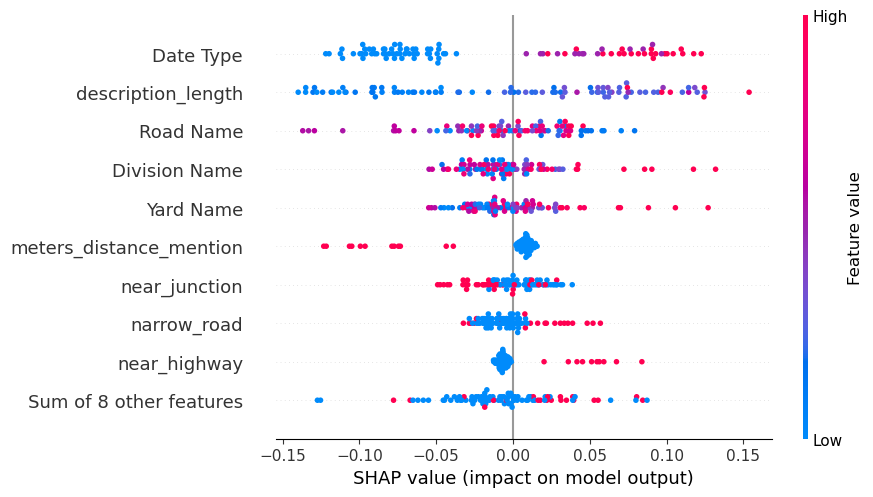

In [ ]:
import shap

explainer = shap.Explainer(rf_classifier, X_train)
shap_values = explainer(X_test)

# Towed class (1)
shap.plots.beeswarm(shap_values[:, :, 1])

                    Feature  Importance
6            zero_tolerance    3.391287
3        footpath_violation    0.840727
11      no_parking_explicit    0.528297
1             near_bus_stop    0.431259
4         both_sides_banned    0.388356
13              market_area    0.370969
2              near_highway    0.332727
9               narrow_road    0.300410
8              date_encoded    0.272758
7        description_length    0.258160
10      residential_society    0.208984
5             near_landmark    0.100912
12  meters_distance_mention    0.026063
0             near_junction    0.014414


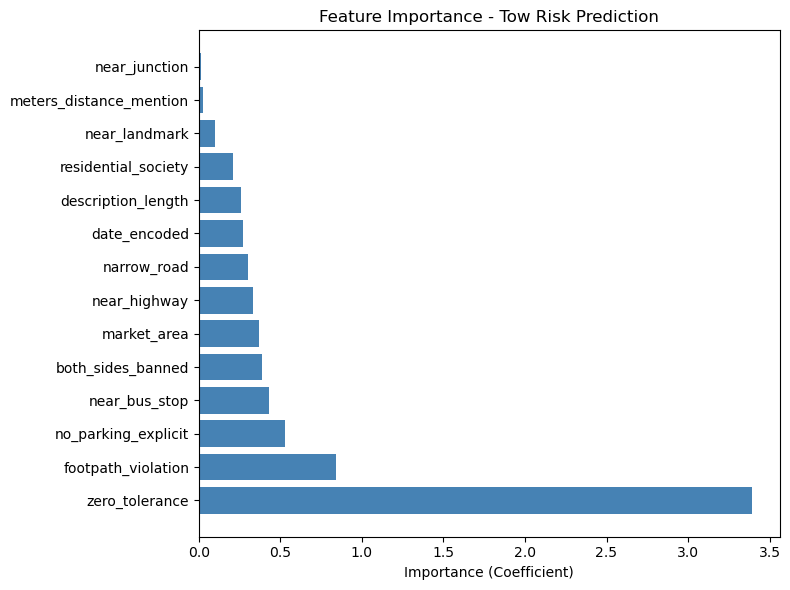

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

data = pd.read_csv(r"C:\Users\Manyata Sachin kadam\Desktop\smart towing intelligence system\Backend\Pune_With_Real_Features_v5.csv", 
                    encoding='latin-1')

le = LabelEncoder()
data['date_encoded'] = le.fit_transform(data['Date Type'])

features = ['near_junction', 'near_bus_stop', 'near_highway',
            'footpath_violation', 'both_sides_banned',
            'near_landmark', 'zero_tolerance',
            'description_length', 'date_encoded',
            'narrow_road', 'residential_society',
            'no_parking_explicit', 'meters_distance_mention',
            'market_area']

X = data[features]
y = data['Towed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Feature Importance (Logistic Regression साठी = coefficients)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

print(importance_df)

# Chart
plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance (Coefficient)')
plt.title('Feature Importance - Tow Risk Prediction')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[11 20]
 [19 40]]
